gabriel

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt

In [3]:
df_sightings = pd.read_csv('./Phalacrocorax carbo.csv',sep=',', low_memory=False)
df_habitats = pd.read_csv('./habitats_cbs_2022.csv', sep=',', low_memory=False)

df = df_sightings.merge(
    df_habitats,
    on=["decimalLatitude", "decimalLongitude"],
    how="inner",
)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558756 entries, 0 to 12558755
Data columns (total 15 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Phalacrocorax carbo        str    
 6   agricultural               float64
 7   built                      float64
 8   coast                      float64
 9   forest                     float64
 10  other                      float64
 11  sand/heather               float64
 12  water                      float64
 13  wetland                    float64
 14  main_habitat               str    
dtypes: float64(11), int64(1), str(3)
memory usage: 1.4 GB


In [5]:
print(df_sightings["Phalacrocorax carbo"].unique())

<StringArray>
[      '0',       '1',       '2',       '4',       '3',       '5',       '6',
       '7',      '10',      '11',      '20',       '9',       '8',      '15',
      '17',      '16',      '12',      '14',      '24',      '22',      '25',
      '21',      '27',      '18',      '50',      '13',      '28',      '26',
      '35',      '23',      '19',      '43',      '56',      '36',      '30',
      '41',      '62',      '32',      '37',      '34',      '31',      '51',
      '67',      '29',      '42',      '55',     '109',      '45',      '57',
      '58',      '38',      '33',      '63',      '-1', 'unknown']
Length: 55, dtype: str


In [6]:
pd.to_datetime(df['eventDate'])
cols = [
    "total_observations",
    "speciesgroup_observations",
    "Phalacrocorax carbo"
]

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

In [ ]:
df.to_csv('bird_and_habitats.csv', index=False)

In [ ]:
print(df.dtypes)

decimalLatitude              float64
decimalLongitude             float64
eventDate                        str
total_observations           float64
speciesgroup_observations      int64
Phalacrocorax carbo            int64
agricultural                 float64
built                        float64
coast                        float64
forest                       float64
other                        float64
sand/heather                 float64
water                        float64
wetland                      float64
main_habitat                     str
dtype: object


In [ ]:
df.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,0.0582,0.0,0.4688,0.0,agricultural


In [ ]:
df.tail(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat
12558751,53.5,6.55,2025-12-27,0.0,0,0,0.0353,0.0,18.4195,0.0,0.0008,0.0,0.0,0.0,coast
12558752,53.5,6.55,2025-12-28,0.0,0,0,0.0353,0.0,18.4195,0.0,0.0008,0.0,0.0,0.0,coast
12558753,53.5,6.55,2025-12-29,0.0,0,0,0.0353,0.0,18.4195,0.0,0.0008,0.0,0.0,0.0,coast
12558754,53.5,6.55,2025-12-30,0.0,0,0,0.0353,0.0,18.4195,0.0,0.0008,0.0,0.0,0.0,coast
12558755,53.5,6.55,2025-12-31,0.0,0,0,0.0353,0.0,18.4195,0.0,0.0008,0.0,0.0,0.0,coast


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
decimalLatitude,12558756.0,52.230060,0.660521,50.75,51.7000,52.2000,52.8000,53.5000
decimalLongitude,12558756.0,5.532783,0.874886,3.35,4.9000,5.6500,6.2000,7.2000
total_observations,12558756.0,8.067763,39.125017,0.00,0.0000,1.0000,6.0000,100040.0000
speciesgroup_observations,12558756.0,4.330658,16.067937,0.00,0.0000,0.0000,2.0000,2779.0000
Phalacrocorax carbo,12558756.0,0.051434,0.336498,0.00,0.0000,0.0000,0.0000,109.0000
agricultural,12558756.0,9.452277,5.147907,0.00,5.3484,10.5682,13.8008,18.1046
built,12558756.0,2.404833,2.419758,0.00,0.7667,1.5599,3.2916,14.3538
coast,12558756.0,1.302932,3.970215,0.00,0.0000,0.0000,0.0000,19.3487
forest,12558756.0,1.621184,2.385737,0.00,0.1494,0.7092,2.0364,16.9985
other,12558756.0,1.501486,1.167872,0.00,0.7249,1.1998,2.0065,10.3983


In [ ]:
print(df[(df['Phalacrocorax carbo'] > 5) & (df['wetland'] == 0)]['main_habitat'].value_counts())

main_habitat
coast           655
built           154
agricultural    138
water            70
other            11
forest            2
Name: count, dtype: int64


In [ ]:
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx

dfX = df[df['Phalacrocorax carbo'] > 5]
my_norm = colors.PowerNorm(gamma=0.4, vmin=5, vmax=160)

plt.figure(figsize=(10, 6.5))
# 1. Plot (notice legend=False)
ax = sns.scatterplot(
    data=dfX, x='decimalLongitude', y='decimalLatitude', 
    hue='Phalacrocorax carbo', hue_norm=my_norm, palette='viridis', legend=False
)

cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)
# 2. Add a colorbar and force your exact numbers onto it
sm = plt.cm.ScalarMappable(cmap='viridis', norm=my_norm)
cbar = plt.colorbar(sm, ax=ax, label='Birds Count')
cbar.set_ticks([5, 10, 20, 50, 100, 160])

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

NameError: name 'df' is not defined

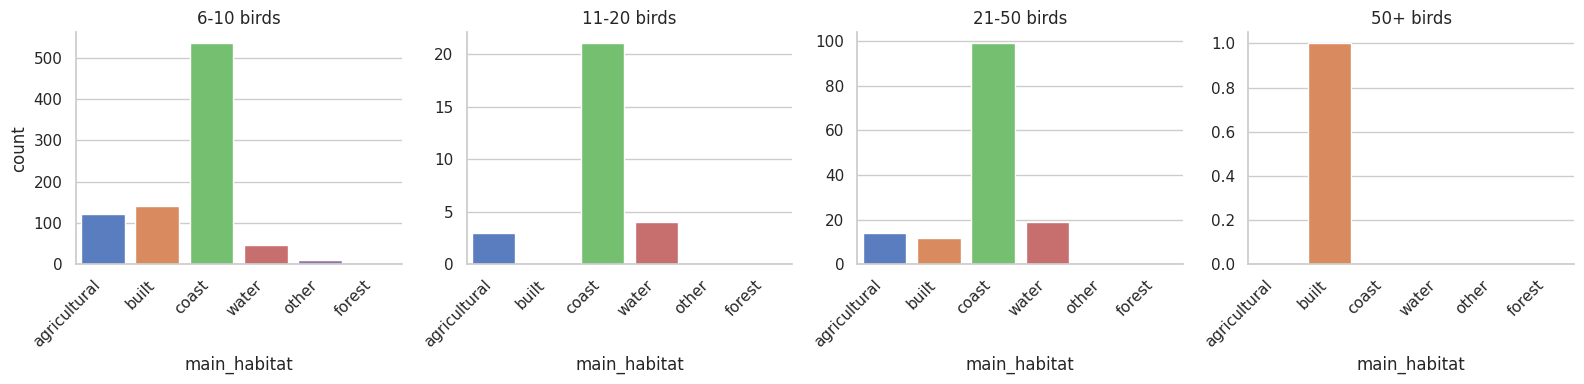

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter out wetlands and bucket the counts
df_non_wetland = df[df['wetland'] == 0].copy()
df_non_wetland['bird_brackets'] = pd.cut(
    df_non_wetland['Phalacrocorax carbo'], 
    bins=[5, 10, 20, 50, float('inf')], 
    labels=['6-10 birds', '11-20 birds', '21-50 birds', '50+ birds']
)
df_filtered = df_non_wetland.dropna(subset=['bird_brackets'])

# 2. Use catplot to split into separate subplots side-by-side
g = sns.catplot(
    data=df_filtered,
    x='main_habitat',
    hue='main_habitat',
    col='bird_brackets',    # Creates a separate plot for each bracket
    kind='count',
    sharey=False,           # CRITICAL: Gives each plot its own Y-axis scale!
    palette='muted',
    height=4,
    aspect=1.0
)

# Rotate habitat labels so they don't overlap
g.set_xticklabels(rotation=45, ha='right')
g.set_titles("{col_name}") # Cleans up the subplot titles

plt.tight_layout()
plt.show()

In [ ]:
# --- convert to numeric ---
cols = [
    "total_observations",
    "speciesgroup_observations",
    "Phalacrocorax carbo"
]

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# --- keep valid coordinates ---
df_clean = df.dropna(subset=["decimalLatitude", "decimalLongitude"])

# --- effort adjustment (important step) ---
df_clean["adjusted_weight"] = (
    df_clean["Phalacrocorax carbo"] /
    (df_clean["total_observations"] + df_clean["speciesgroup_observations"] + 1)
)

In [ ]:
grouped = df_clean.groupby(
    ["decimalLatitude", "decimalLongitude"],
    as_index=False
)["adjusted_weight"].sum()

grouped = grouped[grouped["adjusted_weight"] > 5]

In [ ]:
heat_data = grouped.values.tolist()

m = folium.Map(location=[52.1, 5.3], zoom_start=7)

HeatMap(
    heat_data,
    radius=20,
    blur=15,
    min_opacity=0.1,
    max_zoom=12
).add_to(m)

m.save("heatmap.html")

/tmp/ipykernel_8147/368129399.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


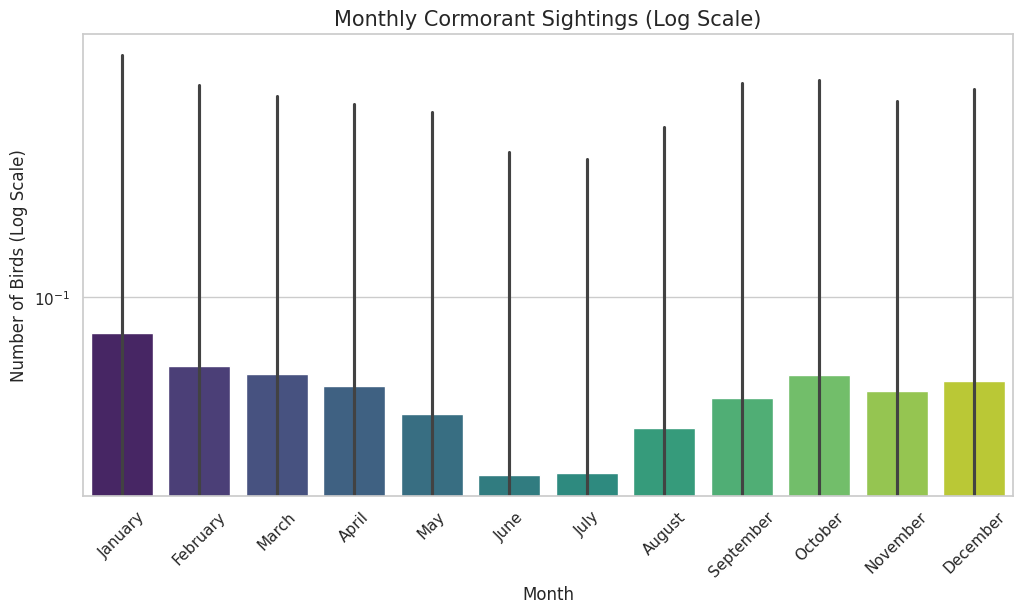

In [ ]:
import numpy as np

# 1. Ensure numeric and handle zeros
# We add a tiny amount (1) to the count if we want to include zero-sighting records 
# in a log plot, otherwise log(0) causes errors.
# 1. Re-create the time features from the eventDate string
df['eventDate'] = pd.to_datetime(df['eventDate'])
df['month_num'] = df['eventDate'].dt.month
df['month_name'] = df['eventDate'].dt.month_name()

# 2. Setup the plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Sort by month_num so it goes Jan -> Dec, not alphabetical
df_sorted = df.sort_values('month_num')

# 4. The Bar Chart
ax = sns.barplot(
    data=df_sorted, 
    x='month_name', 
    y='Phalacrocorax carbo',
    palette='viridis',
    errorbar='sd' # Standard deviation is better for this noisy data
)

# 5. Apply the Log Scale (essential for bird counts)
# We use a small offset (e.g., 0.1) if there are zeros to avoid math errors
ax.set_yscale("log")

# 6. Labels and Formatting
plt.title('Monthly Cormorant Sightings (Log Scale)', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Birds (Log Scale)', fontsize=12)
plt.xticks(rotation=45)

plt.show()

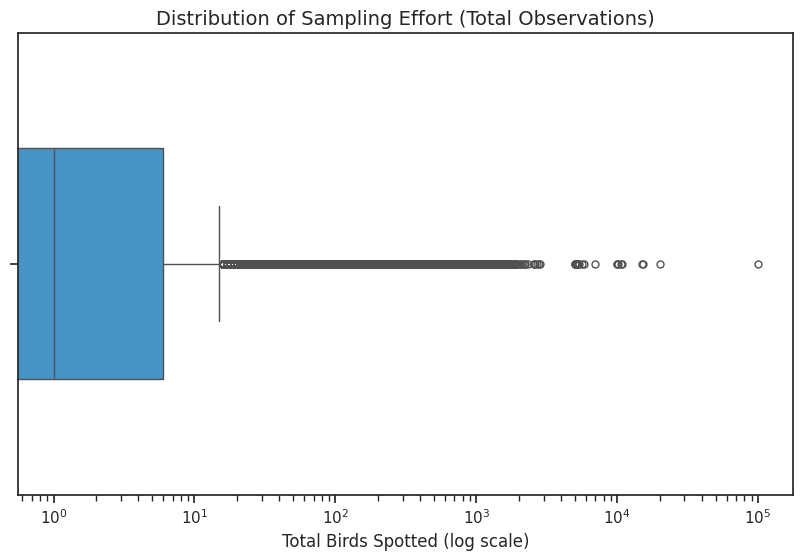

In [ ]:
# 1. Setup the figure
plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks")

# 2. Create the Boxplot
# We'll plot it vertically to see the distribution of effort
ax = sns.boxplot(
    x=df['total_observations'], 
    color='#3498db',
    width=0.5,
    fliersize=5  # Size of the outlier dots
)

# 3. Add a log scale (Highly recommended for 'total_observations')
# Sampling effort usually ranges from 1 to 10,000; without log, 
# the 'box' will look like a flat line at the bottom.
ax.set_xscale("log")

# 4. Labels
plt.title('Distribution of Sampling Effort (Total Observations)', fontsize=14)
plt.xlabel('Total Birds Spotted (log scale)', fontsize=12)

plt.show()

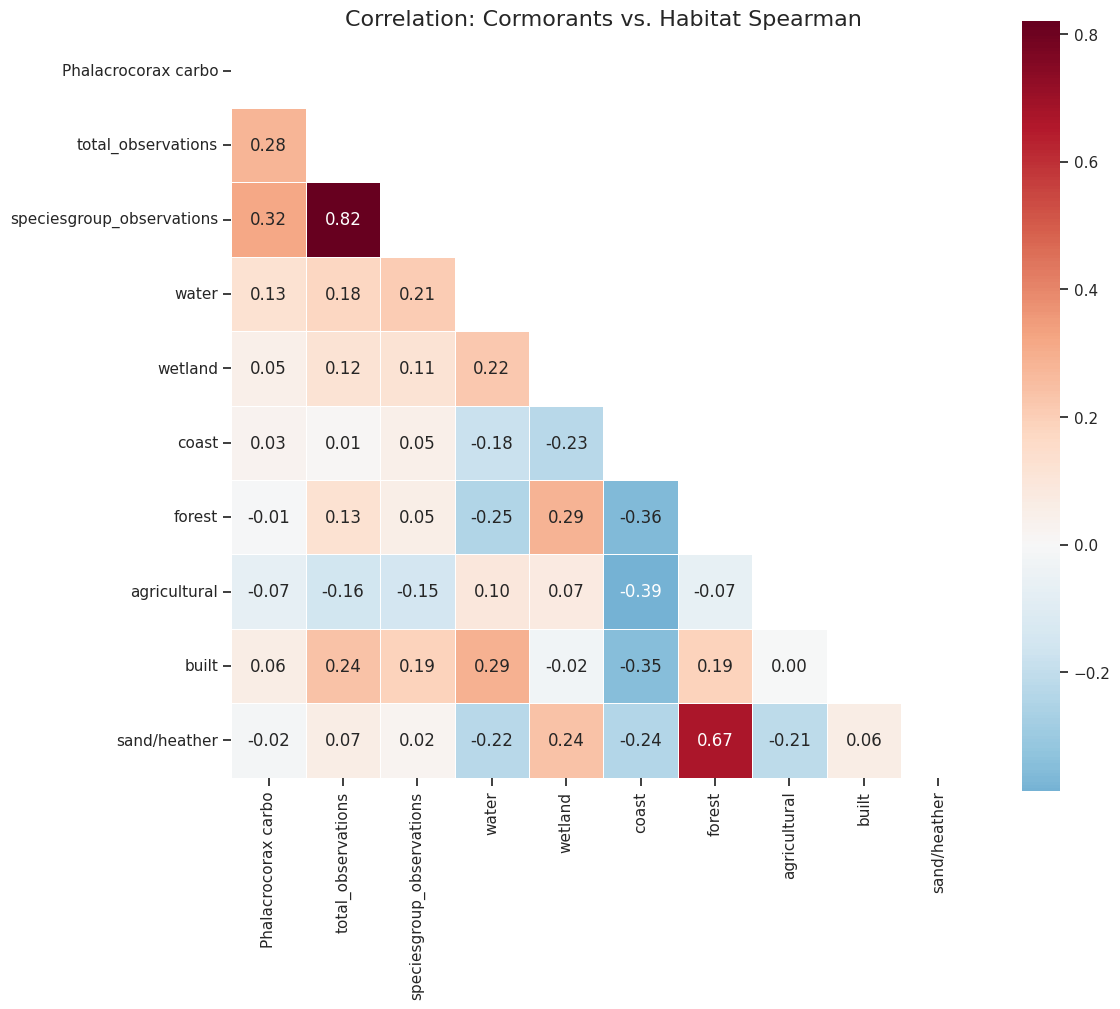

In [ ]:
# 1. Select the target and the new habitat features
habitat_cols = [
    'Phalacrocorax carbo', 'total_observations', 'speciesgroup_observations', 'water', 'wetland', 
    'coast', 'forest', 'agricultural', 'built', 'sand/heather'
]

# Calculate correlation
corr_matrix = df[habitat_cols].corr(method="spearman")

# 2. Plotting
plt.figure(figsize=(12, 10))

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap='RdBu_r', # Red for positive, Blue for negative
    center=0,
    square=True,
    linewidths=.5
)

plt.title('Correlation: Cormorants vs. Habitat Spearman', fontsize=16)
plt.show()

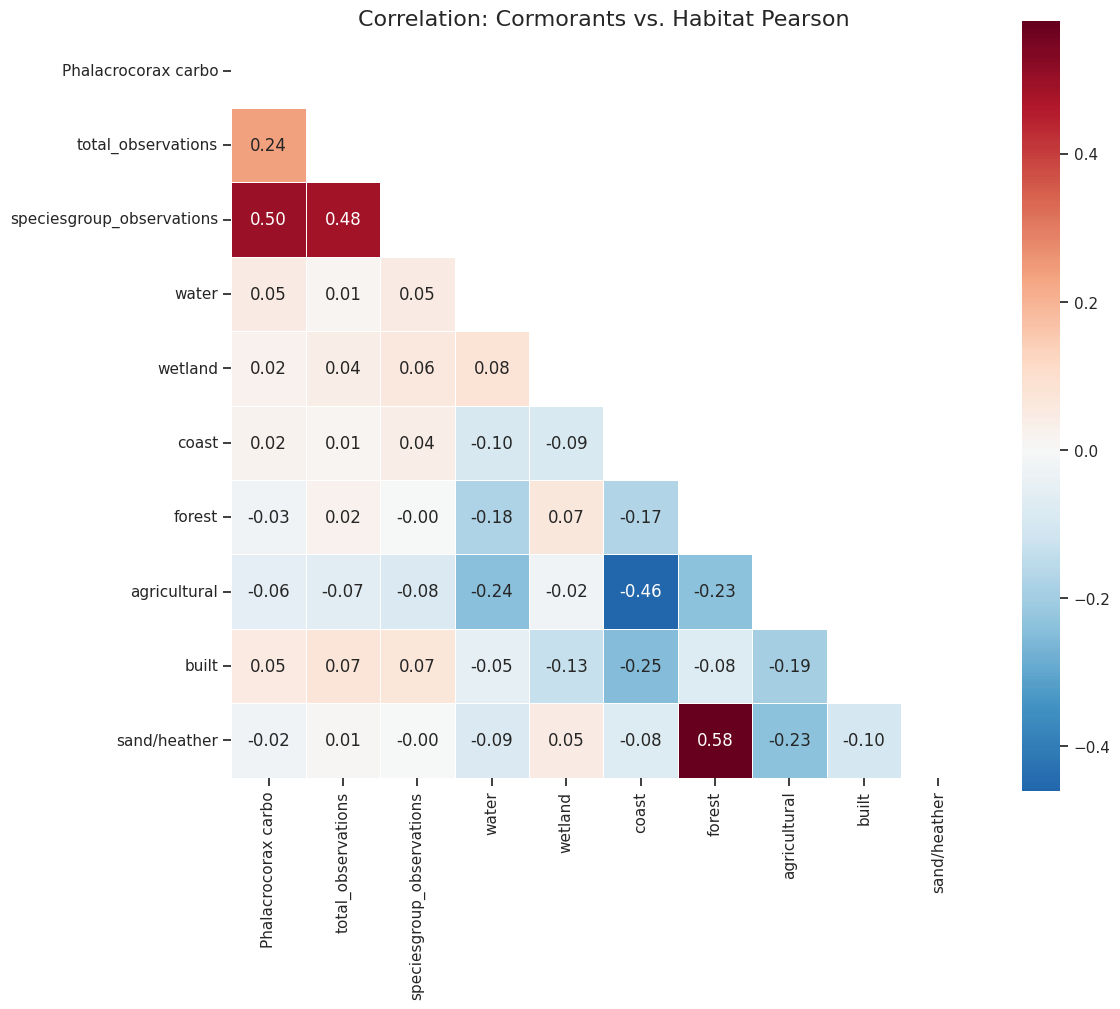

In [ ]:
corr_matrix = df[habitat_cols].corr()

# 2. Plotting
plt.figure(figsize=(12, 10))

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap='RdBu_r', # Red for positive, Blue for negative
    center=0,
    square=True,
    linewidths=.5
)

plt.title('Correlation: Cormorants vs. Habitat Pearson', fontsize=16)
plt.show()

In [ ]:
import folium
from folium.plugins import HeatMap
import pandas as pd

# 1. Use the EXACT same filtered data frame from your scatterplot
dfX = df[df['Phalacrocorax carbo'] > 5].copy()

# 2. Make sure it drops rows missing coordinates (otherwise Folium crashes)
df_folium = dfX.dropna(subset=['decimalLatitude', 'decimalLongitude'])

# 3. Pull the raw, row-by-row data points (no groupby grouping!)
# Structure: [[lat, lon, weight], [lat, lon, weight], ...]
heat_data = df_folium[['decimalLatitude', 'decimalLongitude', 'Phalacrocorax carbo']].values.tolist()

# 4. Initialize the Map with the clean background
m = folium.Map(location=[52.1, 5.3], zoom_start=8, tiles="cartodbpositron")

# 5. Non-Linear Gradient (Mimics your PowerNorm gamma=0.4 scale)
custom_gradient = {
    0.00: 'blue',    # Closer to 5 birds
    0.05: 'cyan',    # ~10 birds
    0.15: 'green',   # ~20 birds
    0.50: 'yellow',  # ~50 birds
    1.00: 'red'      # 100+ birds
}

# 6. Add the HeatMap
HeatMap(
    heat_data,
    radius=15,             # Tight radius matches scatter dot sizing
    blur=10,               
    min_opacity=0.3,       
    max_val=100,           # Matches your vmax=100 from the scatterplot
    gradient=custom_gradient
).add_to(m)

m.save("heatmap_exact_match.html")

/tmp/ipykernel_8147/1981997395.py:28: UserWarning: The `max_val` parameter is no longer necessary. The largest intensity is calculated automatically.
  HeatMap(
